# Step 4: Machine Learning Models

In this step, we build and compare:

- Linear Regression
- XGBoost Regressor

The objective is to predict medical insurance charges using customer demographic and lifestyle characteristics.

## 1. Import Libraries

In [ ]:
!conda install -y xgboost

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

## 2. Load Processed Dataset

In [11]:
df = pd.read_csv("insurance_model_ready.csv")

print(df.shape)

df.head()

(1337, 21)


,age,sex,bmi,children,smoker,charges,high_bmi,smoker_binary,smoker_bmi_interaction,family_size,...,region_northwest,region_southeast,region_southwest,age_group_31-40,age_group_41-50,age_group_51-60,age_group_61-70,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,0,27.900,0,1,16884.92400,0,1,27.9,1,...,0,0,1,0,0,0,0,0,1,0
1,18,1,33.770,1,0,1725.55230,1,0,0.0,2,...,0,1,0,0,0,0,0,0,0,1
2,28,1,33.000,3,0,4449.46200,1,0,0.0,4,...,0,1,0,0,0,0,0,0,0,1
3,33,1,22.705,0,0,21984.47061,0,0,0.0,1,...,1,0,0,1,0,0,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,0,0.0,1,...,1,0,0,1,0,0,0,0,1,0


## 3. Define Features and Target

We use `charges` as the target variable.

In [12]:
X = df.drop(
    columns=[
        'charges',
        'log_charges'
    ],
    errors='ignore'
)

y = df['charges']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1337, 19)
Target: (1337,)


## 4. Train-Test Split

We reserve 20% of the data for testing.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1069, 19)
Testing Set: (268, 19)


## 5. Linear Regression Model

In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## 6. Evaluate Linear Regression

In [16]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("-" * 30)
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))

Linear Regression Results
------------------------------
MAE : 2837.29
RMSE: 4575.55
R²  : 0.8861


## 7. Feature Importance (Linear Regression)

The coefficients indicate the direction and magnitude of influence on insurance charges.

In [17]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
18,bmi_category_Obese,7668.562286
7,smoker_bmi_interaction,1467.944483
16,bmi_category_Normal,1236.744357
17,bmi_category_Overweight,1156.227403
15,age_group_61-70,468.476110
3,children,348.329451
8,family_size,348.329451
0,age,257.240114
14,age_group_51-60,-162.903090
2,bmi,-211.946206


## 8. XGBoost Model

XGBoost can capture non-linear relationships and interactions between variables.

In [18]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

## 9. Evaluate XGBoost

In [19]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Results")
print("-" * 30)
print("MAE :", round(mae_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("R²  :", round(r2_xgb, 4))

XGBoost Results
------------------------------
MAE : 2458.45
RMSE: 4324.98
R²  : 0.8982


## 10. Hyperparameter Tuning: XGBoost

We use Grid Search with Cross Validation to find the optimal combination of parameters.

In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [25]:
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [28]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
       

In [29]:
print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)

print("\nBest Cross Validation R²:")
print(round(grid_xgb.best_score_, 4))

Best XGBoost Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best Cross Validation R²:
0.8457


In [30]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

In [31]:
mae_xgb_tuned = mean_absolute_error(
    y_test,
    y_pred_xgb_tuned
)

rmse_xgb_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb_tuned
    )
)

r2_xgb_tuned = r2_score(
    y_test,
    y_pred_xgb_tuned
)

print("Tuned XGBoost Results")
print("-" * 30)
print("MAE :", round(mae_xgb_tuned, 2))
print("RMSE:", round(rmse_xgb_tuned, 2))
print("R²  :", round(r2_xgb_tuned, 4))

Tuned XGBoost Results
------------------------------
MAE : 2463.82
RMSE: 4286.18
R²  : 0.9


## 10. XGBoost Feature Importance

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
7,smoker_bmi_interaction,0.826519
4,smoker,0.089521
0,age,0.028064
16,bmi_category_Normal,0.008500
3,children,0.008387
14,age_group_51-60,0.006951
2,bmi,0.005905
9,region_northwest,0.005794
17,bmi_category_Overweight,0.005108
10,region_southeast,0.004254


## 11. Visualize Feature Importance

# Feature Evaluation

To identify the factors that most influence medical insurance charges, three complementary methods were used:

1. Linear Regression Coefficients (Interpretability)
2. Tuned XGBoost Feature Importance (Predictive Importance)
3. Correlation Analysis (Relationship Strength)

Using multiple approaches helps validate that the identified risk factors are consistently important across different analytical methods.

## Linear Regression Coefficients

The coefficients show the direction and magnitude of each feature's impact on insurance charges.

- Positive coefficient → increases charges
- Negative coefficient → decreases charges

Features with larger absolute coefficients have a stronger effect on predicted insurance costs.

In [37]:
# Create coefficient dataframe

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

# Sort by absolute importance
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
4,smoker,-10729.470104,10729.470104
6,smoker_binary,-10729.470104,10729.470104
18,bmi_category_Obese,7668.562286,7668.562286
5,high_bmi,-3254.469410,3254.469410
7,smoker_bmi_interaction,1467.944483,1467.944483
12,age_group_31-40,-1465.300532,1465.300532
16,bmi_category_Normal,1236.744357,1236.744357
17,bmi_category_Overweight,1156.227403,1156.227403
13,age_group_41-50,-897.132962,897.132962
11,region_southwest,-892.908035,892.908035


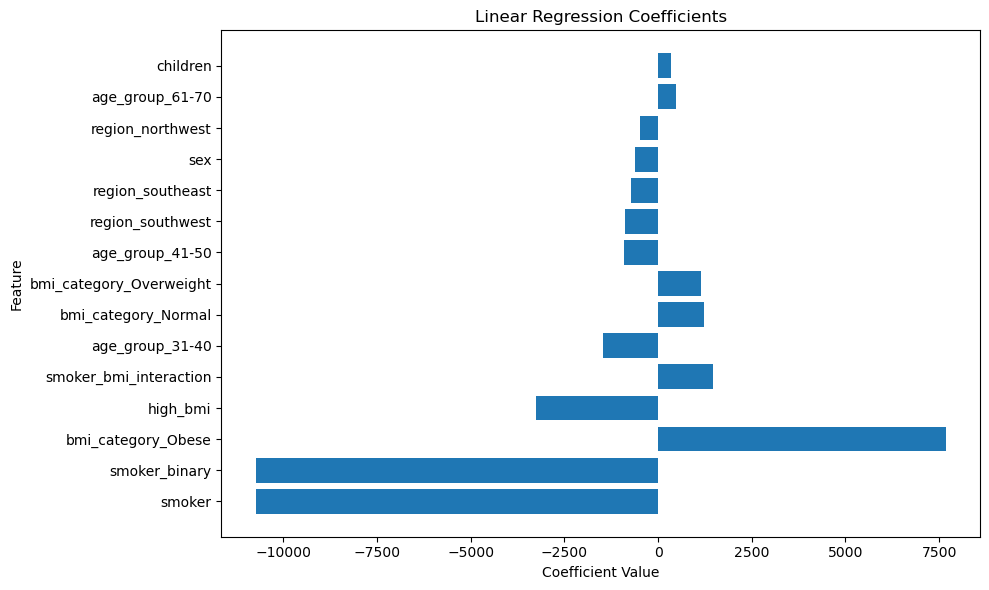

In [38]:
import matplotlib.pyplot as plt

top_coef = coef_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_coef['Feature'],
    top_coef['Coefficient']
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## XGBoost Feature Importance

Feature importance measures how much each variable contributes to reducing prediction error within the model.

Higher importance values indicate a stronger contribution to predicting insurance charges.

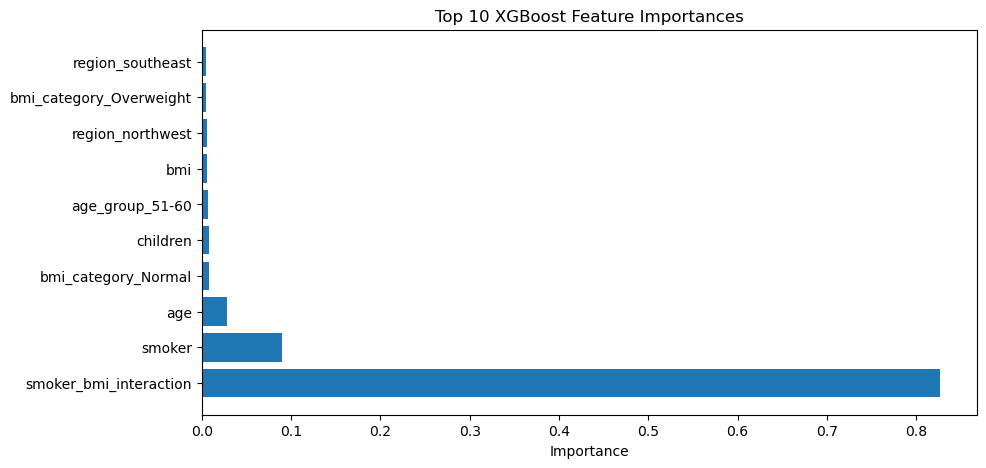

In [22]:
import matplotlib.pyplot as plt
importance_top = importance.head(10)

plt.figure(figsize=(10, 5))

plt.barh(
    importance_top['Feature'],
    importance_top['Importance']
)

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")

plt.show()

## Tuned XGBoost Feature Importance

Feature importance measures how much each variable contributes to reducing prediction error within the model.

Higher importance values indicate a stronger contribution to predicting insurance charges.

In [39]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
7,smoker_bmi_interaction,0.805778
4,smoker,0.090505
0,age,0.038988
2,bmi,0.017987
3,children,0.012164
9,region_northwest,0.006980
17,bmi_category_Overweight,0.005743
1,sex,0.005578
11,region_southwest,0.005182
10,region_southeast,0.004611


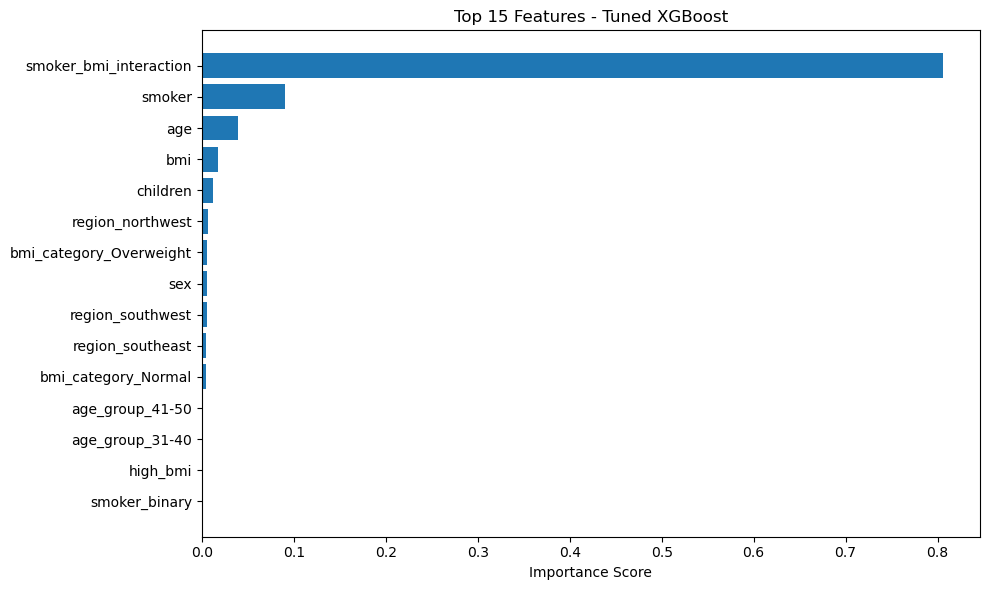

In [44]:
top_importance = importance_df.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10,6))

plt.barh(
    top_importance['Feature'],
    top_importance['Importance']
)

plt.title("Top 15 Features - Tuned XGBoost")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

## Correlation Analysis

To include categorical variables in the correlation analysis, smoking status and gender are encoded as binary variables.

The heatmap shows the strength and direction of relationships between variables.

Correlation values range from:

- +1 → strong positive relationship
- 0 → no relationship
- -1 → strong negative relationship

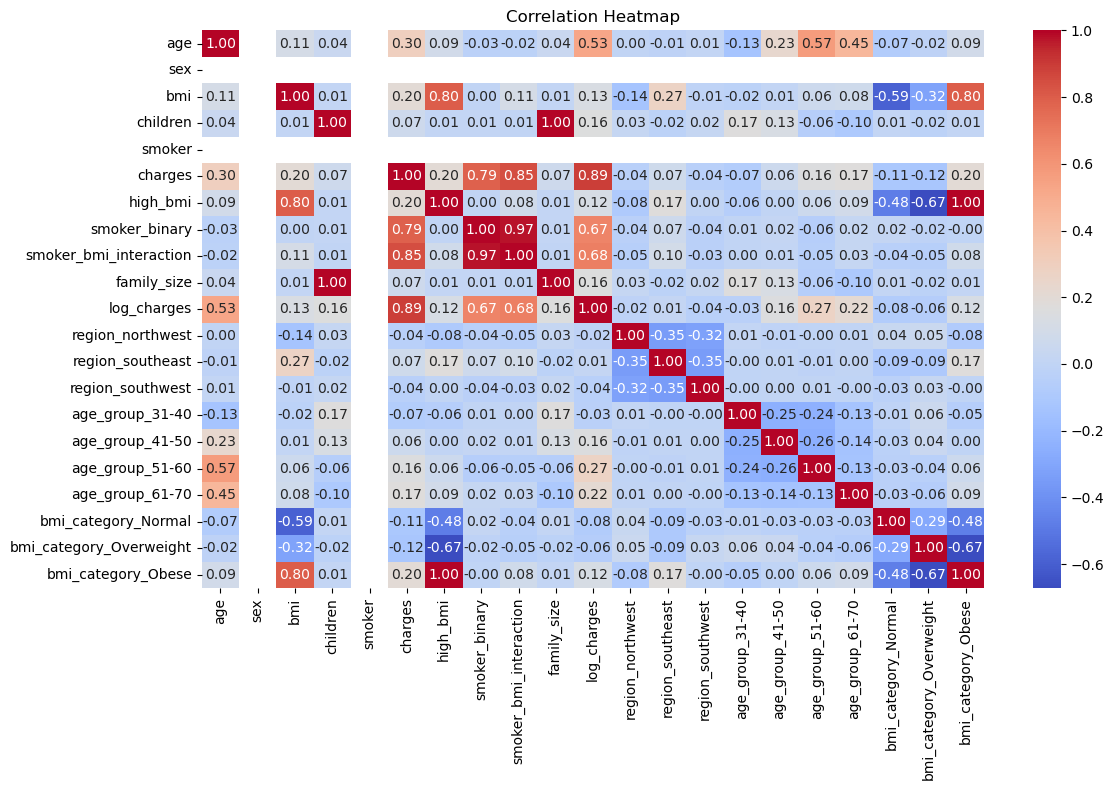

In [42]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

# Feature Evaluation Summary

The three evaluation methods consistently identified the same key risk factors:

1. Smoking Status
2. Age
3. BMI

Key findings:

- Smoking status showed the strongest relationship with insurance charges across all analyses.
- Age was positively associated with higher medical costs.
- BMI contributed significantly to insurance risk, particularly for individuals with higher BMI values.
- Variables such as gender, number of children, and region showed weaker effects on insurance charges.

The consistency across Linear Regression, XGBoost, and Correlation Analysis increases confidence that these factors are the primary drivers of medical insurance costs in this dataset.

# 12. Model Comparison

Model performance is evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

A lower MAE and RMSE indicate better predictive accuracy.

A higher R² indicates that the model explains a larger proportion of the variation in insurance charges.

In [34]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'MAE': [
        2837.29,
        2458.45,
        mae_xgb_tuned
    ],
    'RMSE': [
        4575.55,
        4324.98,
        rmse_xgb_tuned
    ],
    'R²': [
        0.8861,
        0.8982,
        r2_xgb_tuned
    ]
})

comparison.sort_values(
    by='R²',
    ascending=False
)

,Model,MAE,RMSE,R²
2,Tuned XGBoost,2463.819884,4286.183317,0.900023
1,XGBoost,2458.450000,4324.980000,0.898200
0,Linear Regression,2837.290000,4575.550000,0.886100


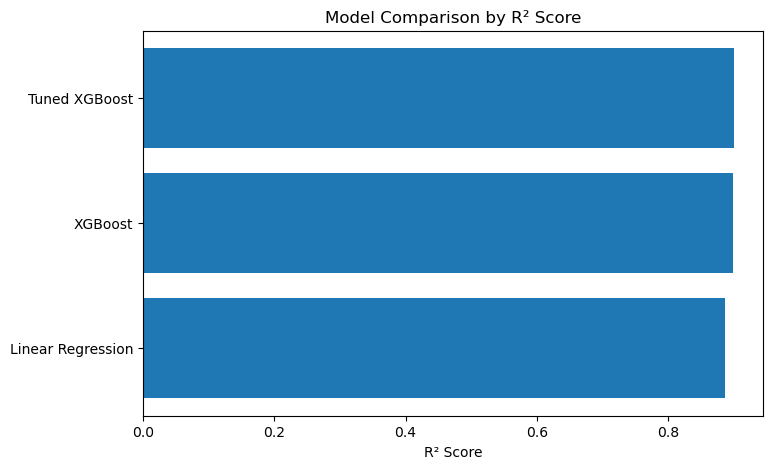

In [35]:
import matplotlib.pyplot as plt

comparison_sorted = comparison.sort_values(
    by='R²',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    comparison_sorted['Model'],
    comparison_sorted['R²']
)

plt.title("Model Comparison by R² Score")
plt.xlabel("R² Score")

plt.show()

# Model Evaluation Summary

Three machine learning models were developed and evaluated to predict medical insurance charges:

- Linear Regression
- XGBoost
- Tuned XGBoost

## Results

| Model | MAE | RMSE | R² |
|---------|---------:|---------:|---------:|
| Linear Regression | 2837.29 | 4575.55 | 0.8861 |
| XGBoost | 2458.45 | 4324.98 | 0.8982 |
| Tuned XGBoost | 2463.82 | 4286.18 | 0.9000 |

## Key Findings

- Both XGBoost models outperformed Linear Regression across all major performance metrics.
- The Tuned XGBoost model achieved the highest R² score (0.9000), explaining approximately 90% of the variability in insurance charges.
- The Tuned XGBoost model also achieved the lowest RMSE, indicating better overall prediction accuracy and fewer large prediction errors.
- The standard XGBoost model achieved the lowest MAE, although the difference compared to the tuned version was minimal.

## Final Model Selection

The Tuned XGBoost model was selected as the final model because it provided the best overall balance of predictive performance, achieving the highest explanatory power and the lowest RMSE.

These results suggest that insurance costs are influenced by complex, non-linear relationships that are captured more effectively by XGBoost than by Linear Regression.

# Business Insight

The analysis identified smoking status, age, and BMI as the most important factors influencing medical insurance costs.

Key business implications:

- Smokers represent the highest-risk customer group and incur substantially higher healthcare costs.
- Insurance charges increase with age, reflecting greater healthcare utilization among older individuals.
- Higher BMI levels are associated with increased medical expenses and insurance risk.

The Tuned XGBoost model can be used to support risk-based pricing strategies by estimating expected healthcare costs for individual customers.

By incorporating predictive analytics into pricing decisions, insurers can:

- Improve premium accuracy
- Better segment customers by risk level
- Reduce pricing uncertainty
- Support data-driven underwriting decisions

This approach demonstrates how machine learning can enhance traditional insurance pricing methodologies while improving predictive performance.

In [45]:
import pickle

# save tuned model
pickle.dump(grid_xgb.best_estimator_, open("best_xgb.pkl", "wb"))

In [46]:
pickle.dump(X.columns, open("model_columns.pkl", "wb"))